In [1]:
!pip install transformers --quiet
!pip install opendatasets --quiet

In [ ]:
!pip install transformers --quiet

In [5]:
import opendatasets as od
kaggleURL = "https://www.kaggle.com/datasets/"
kaggleDataset = "rmisra/news-headlines-dataset-for-sarcasm-detection"
od.download(kaggleURL + kaggleDataset)

Skipping, found downloaded files in "./news-headlines-dataset-for-sarcasm-detection" (use force=True to force download)


In [6]:
dataset_folder = 'news-headlines-dataset-for-sarcasm-detection'
json_file = 'Sarcasm_Headlines_Dataset_v2.json'
full_path = dataset_folder + '/' + json_file
print(full_path)

news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset_v2.json


In [7]:
import torch 
import torch.nn as nn
from torch.optim import Adam
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'I am on {device}')

I am on cuda


In [8]:
df = pd.read_json(full_path, lines=True)
df = df.drop(['article_link'], axis=1) #axis=1 columns
df.head()

,is_sarcastic,headline
0,1,thirtysomething scientists unveil doomsday clo...
1,0,dem rep. totally nails why congress is falling...
2,0,eat your veggies: 9 deliciously different recipes
3,1,inclement weather prevents liar from getting t...
4,1,mother comes pretty close to using word 'strea...


In [9]:
new_order = ['headline', 'is_sarcastic']
df = df[new_order]
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [10]:
X_train, X_test, y_train, y_test = train_test_split(np.array(df['headline']),np.array(df['is_sarcastic']), test_size=0.3 )

In [11]:
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5)

In [18]:
print('Shape of X train dataset:', X_train.shape[0], 'which is', round(X_train.shape[0]/df.shape[0], 4), '% of the entire Dataset')
print('Shape of X test dataset:', X_test.shape[0], 'which is', round(X_test.shape[0]/df.shape[0], 4), '% of the entire Dataset')
print('Shape of X validation dataset:', X_val.shape[0], 'which is', round(X_val.shape[0]/df.shape[0], 4), '% of the entire Dataset')

Shape of X train dataset: 20033 which is 0.7 % of the entire Dataset
Shape of X test dataset: 4293 which is 0.15 % of the entire Dataset
Shape of X validation dataset: 4293 which is 0.15 % of the entire Dataset


In [50]:
#Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
#The model itself is not needed for the Dataset class, but for training later.
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased") 

class CustomDataset(Dataset):
    def __init__(self, X, Y, tokenizer):
        # Ensure every item in X is a string
        X = [str(x) for x in X]

        self.X = tokenizer(
            X,
            max_length=100,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.Y)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.X.items()}
        item['labels'] = self.Y[idx]
        return item

In [51]:
training_data = CustomDataset(X_train, y_train, tokenizer)
validation_data = CustomDataset(X_val, y_val, tokenizer)
testing_data = CustomDataset(X_test, y_test, tokenizer)

In [52]:
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

In [53]:
train_dataloader = DataLoader(training_data, batch_size = BATCH_SIZE, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = BATCH_SIZE, shuffle = True)
test_dataloader = DataLoader(testing_data, batch_size = BATCH_SIZE, shuffle = True)

In [54]:
class MyModel(nn.Module):
    def __init__(self, bert):
        super(MyModel, self).__init__()
        
        self.bert = bert
        self.dropout = nn.Dropout(0.25)
        self.linear1 = nn.Linear(768, 384)
        self.linear2 = nn.Linear(384, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, input_ids, attention_mask):
        # Pass data through the BERT model.
        bert_output = self.bert(input_ids=input_ids,
                                attention_mask=attention_mask,
                                return_dict=False)
        pooled_output = bert_output[0][:, 0]
        
        output = self.linear1(pooled_output)
        output = self.dropout(output)
        output = self.linear2(output)
        output = self.sigmoid(output)
        
        return output

In [56]:
for param in bert_model.parameters():
    param.requires_grad = False
model = MyModel(bert_model).to(device)

In [57]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = LR) 

In [65]:
total_loss_train_plot = []
total_accuracy_train_plot = []
total_loss_validation_plot = []
total_accuracy_validation_plot = []

for epoch in range(EPOCHS):
    model.train()
    total_loss_train = []
    total_accuracy_train = []

    for indx, batch in enumerate(train_dataloader):
        inputs = {key: val.to(device) for key, val in batch.items() if key != 'labels'}
        labels = batch['labels'].to(device)

        predictions = model(
            input_ids=inputs['input_ids'].squeeze(1),
            attention_mask=inputs['attention_mask'].squeeze(1)
        ).squeeze(1)

        batch_loss = criterion(predictions, labels)
        total_loss_train.append(batch_loss.item())

        accuracy = (predictions.round() == labels).sum().item()
        total_accuracy_train.append(accuracy)

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    model.eval()
    total_loss_validation = []
    total_accuracy_validation = []

    with torch.no_grad():
        for indx, batch in enumerate(validation_dataloader):
            inputs = {key: val.to(device) for key, val in batch.items() if key != 'labels'}
            labels = batch['labels'].to(device)

            predictions = model(
                input_ids=inputs['input_ids'].squeeze(1),
                attention_mask=inputs['attention_mask'].squeeze(1)
            ).squeeze(1)

            batch_loss = criterion(predictions, labels)
            total_loss_validation.append(batch_loss.item())

            accuracy = (predictions.round() == labels).sum().item()
            total_accuracy_validation.append(accuracy)

    # Epoch metrics
    avg_train_loss = sum(total_loss_train) / len(total_loss_train)
    avg_val_loss = sum(total_loss_validation) / len(total_loss_validation)

    total_train_correct = sum(total_accuracy_train)
    total_val_correct = sum(total_accuracy_validation)

    train_accuracy = (total_train_correct / len(training_data)) * 100
    val_accuracy = (total_val_correct / len(validation_data)) * 100

    total_loss_train_plot.append(round(avg_train_loss, 4))
    total_loss_validation_plot.append(round(avg_val_loss, 4))
    total_accuracy_train_plot.append(round(train_accuracy, 4))
    total_accuracy_validation_plot.append(round(val_accuracy, 4))

    print(f"""
    Epoch {epoch + 1}
    ---------------------------
    Train Loss: {round(avg_train_loss, 4)}
    Train Accuracy: {round(train_accuracy, 2)}%
    Validation Loss: {round(avg_val_loss, 4)}
    Validation Accuracy: {round(val_accuracy, 2)}%
    """)



    Epoch 1
    ---------------------------
    Train Loss: 0.4835
    Train Accuracy: 78.04%
    Validation Loss: 0.4052
    Validation Accuracy: 82.48%
    

    Epoch 2
    ---------------------------
    Train Loss: 0.4127
    Train Accuracy: 81.97%
    Validation Loss: 0.3753
    Validation Accuracy: 83.86%
    

    Epoch 3
    ---------------------------
    Train Loss: 0.3949
    Train Accuracy: 82.67%
    Validation Loss: 0.356
    Validation Accuracy: 84.32%
    

    Epoch 4
    ---------------------------
    Train Loss: 0.3845
    Train Accuracy: 82.87%
    Validation Loss: 0.3585
    Validation Accuracy: 84.11%
    

    Epoch 5
    ---------------------------
    Train Loss: 0.3941
    Train Accuracy: 83.02%
    Validation Loss: 0.3485
    Validation Accuracy: 84.56%
    

    Epoch 6
    ---------------------------
    Train Loss: 0.3846
    Train Accuracy: 83.2%
    Validation Loss: 0.3514
    Validation Accuracy: 84.67%
    

    Epoch 7
    -------------------------

In [83]:
with torch.no_grad():
    total_loss_test = 0
    total_accuracy_test = 0

    for indx, data in enumerate(test_dataloader):
        inputs = {key: val.to(device) for key, val in data.items() if key != 'labels'}
        labels = data['labels'].to(device)

        predictions = model(
            inputs["input_ids"].squeeze(1),
            inputs["attention_mask"].squeeze(1)
        ).squeeze(1)

        batch_loss = criterion(predictions, labels)
        total_loss_test += batch_loss.item()

        accuracy = (predictions.round() == labels).sum().item()
        total_accuracy_test += accuracy

# Final test accuracy print
test_accuracy_percent = round((total_accuracy_test / len(testing_data)) * 100, 4)
print(f"Accuracy Score on Testing Data is: {test_accuracy_percent}%")


Accuracy Score on Testing Data is: 85.2784%


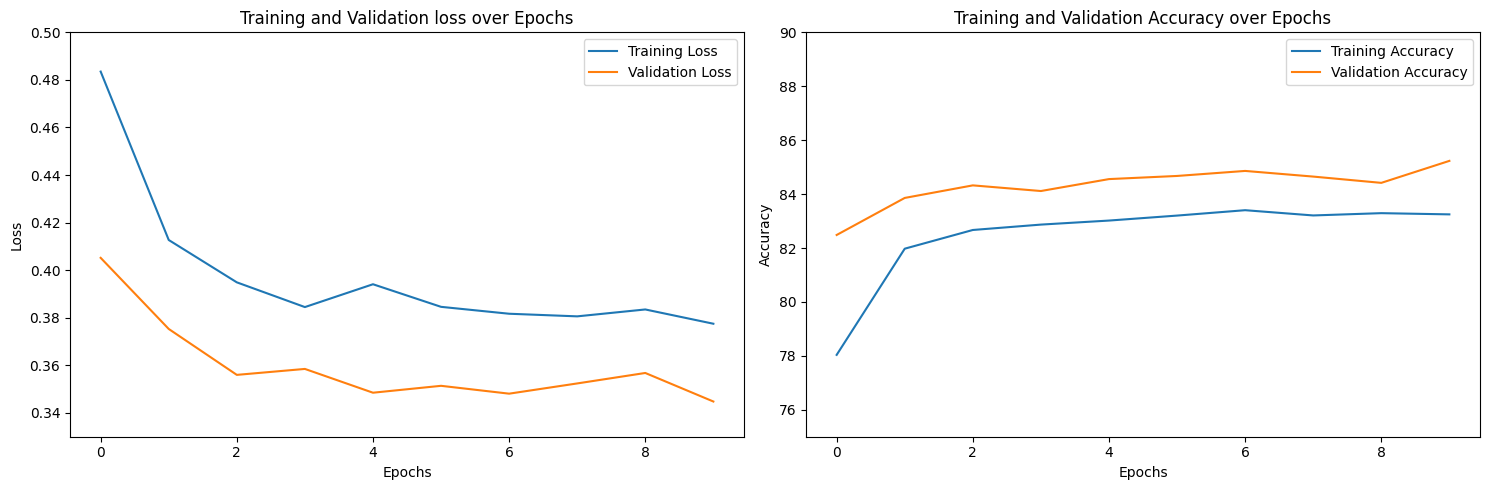

In [88]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize=(15,5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0.33, 0.5])
axs[0].legend()


axs[1].plot(total_accuracy_train_plot, label = 'Training Accuracy')
axs[1].plot(total_accuracy_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([75, 90])
axs[1].legend()

plt.tight_layout()
plt.show()